In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf

In [2]:
'''
Create vegetation land masks
'''
ERA5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/FWI_6month_fire_season_ERA5_resolution.nc')
d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')

vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]
era5_combined = (vege_ds.lai_hv + vege_ds.lai_lv).max('time')
era5_vege_mask = era5_combined.where(era5_combined>3.5)

vege_ds_coarsened = vege_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()

cam5_vege = vege_ds_coarsened.interp(longitude=cam5.longitude, latitude=cam5.latitude, method="linear")
cam5_combined = (cam5_vege.lai_hv + cam5_vege.lai_lv).max('time')
cam5_vege_mask = cam5_combined.where(cam5_combined>3.5)

d4pdf_vege = vege_ds_coarsened.interp(longitude=d4pdf.longitude, latitude=d4pdf.latitude, method="linear")
d4pdf_combined = (d4pdf_vege.lai_hv + d4pdf_vege.lai_lv).max('time')
d4pdf_vege_mask = d4pdf_combined.where(d4pdf_combined>3.5)

box = [(32,55),(232,256)]

In [25]:
'''
CAM5
'''

start_year, end_year = ('1959','2014')

for scen in ['All','Nat']:
    era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
    runs = {'All':[i for i in range(1,11)] + [i for i in range(36,44)] + [i for i in range(61,71)] + [i for i in range(86,101)],
            'Nat':[i for i in range(1,11)] + [i for i in range(36,51)] + [i for i in range(61,71)] + [i for i in range(86,96)] + [i for i in range(97,101)]}
    vege_mask = cam5_vege_mask
    
    ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_'+scen+'_ensMean.nc')
    ens_mean = ens_mean.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
    ens_mean.where(vege_mask>0)
    ens_mean = ens_mean.sel(time=slice(start_year,end_year))
    ens_mean = ens_mean.where(~era5_da.isnull())
    

    for ens_mem in runs[scen]:
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

        mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_'+scen+'_run'+number+'.nc')
        mem_da = mem_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        mem_da = mem_da.where(vege_mask>0)
        mem_da = mem_da.sel(time=slice(start_year,end_year))
        mem_da = mem_da.where(~era5_da.isnull())

        noise = mem_da - ens_mean
        abs_noise = abs(noise)
        trend_da = xr.apply_ufunc(get_linregress_slope, noise, input_core_dims=[["time"]], vectorize = True)
        
        #noise.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/noise/FWI_noise_'+scen+'_run'+number+'.nc')
        #abs_noise.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/noise/absolute_noise/FWI_absolute_noise_'+scen+'_run'+number+'.nc')
        trend_da.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/noise/trend/FWI_noise_trend_'+scen+'_run'+number+'.nc')



In [26]:
'''
d4PDF-G
'''


start_year, end_year = ('1951','2021')

for scen in ['HPB','HPB_NAT']:
    era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
    runs = {'HPB':range(1,101),
            'HPB_NAT':range(1,101)}
    vege_mask = d4pdf_vege_mask
    
    ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_'+scen+'_ensMean.nc')
    ens_mean = ens_mean.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
    ens_mean.where(vege_mask>0)
    ens_mean = ens_mean.sel(time=slice(start_year,end_year))
    ens_mean = ens_mean.where(~era5_da.isnull())
    

    for ens_mem in runs[scen]:
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

        mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_'+scen+'_m'+number+'.nc')
        mem_da = mem_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        mem_da = mem_da.where(vege_mask>0)
        mem_da = mem_da.sel(time=slice(start_year,end_year))
        mem_da = mem_da.where(~era5_da.isnull())

        noise = mem_da - ens_mean
        abs_noise = abs(noise)
        trend_da = xr.apply_ufunc(get_linregress_slope, noise, input_core_dims=[["time"]], vectorize = True)
        
        #noise.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/noise/FWI_noise_'+scen+'_m'+number+'.nc')
        #abs_noise.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/noise/absolute_noise/FWI_absolute_noise_'+scen+'_m'+number+'.nc')
        trend_da.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/noise/trend/FWI_noise_trend_'+scen+'_m'+number+'.nc')


In [39]:
start_year, end_year = ('1951','2021')

for scen in ['HPB','HPB_NAT']:
    era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
    runs = {'HPB':range(1,101),
            'HPB_NAT':range(1,101)}

    das = []
    for ens_mem in runs[scen]:
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)


        trend_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/noise/trend/FWI_noise_trend_'+scen+'_m'+number+'.nc')
        
        das.append(trend_da)
        
    ensemble_da = xr.concat(das,dim='member')
    std_da = ensemble_da.std('member')
    std_da.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/noise/trend/FWI_noise_trend_'+scen+'_ensSTD.nc')
    

start_year, end_year = ('1959','2014')

for scen in ['All','Nat']:
    runs = {'All':[i for i in range(1,11)] + [i for i in range(36,44)] + [i for i in range(61,71)] + [i for i in range(86,101)],
            'Nat':[i for i in range(1,11)] + [i for i in range(36,51)] + [i for i in range(61,71)] + [i for i in range(86,96)] + [i for i in range(97,101)]}

    das = []
    for ens_mem in runs[scen]:
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)


        trend_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/noise/trend/FWI_noise_trend_'+scen+'_run'+number+'.nc')

        das.append(trend_da)
        
    ensemble_da = xr.concat(das,dim='member')
    std_da = ensemble_da.std('member')
    std_da.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/noise/trend/FWI_noise_trend_'+scen+'_ensSTD.nc')



/home/queenle/.local/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1667: RuntimeWarning: Degrees of freedom <= 0 for slice.
  keepdims=keepdims)
/home/queenle/.local/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1667: RuntimeWarning: Degrees of freedom <= 0 for slice.
  keepdims=keepdims)
/home/queenle/.local/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1667: RuntimeWarning: Degrees of freedom <= 0 for slice.
  keepdims=keepdims)
/home/queenle/.local/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1667: RuntimeWarning: Degrees of freedom <= 0 for slice.
  keepdims=keepdims)


In [40]:
d4pdf_all_trend_ensSTD = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/noise/trend/FWI_noise_trend_HPB_ensSTD.nc')
d4pdf_nat_trend_ensSTD = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/noise/trend/FWI_noise_trend_HPB_NAT_ensSTD.nc')
cam5_all_trend_ensSTD = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/noise/trend/FWI_noise_trend_All_ensSTD.nc')
cam5_nat_trend_ensSTD = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/noise/trend/FWI_noise_trend_Nat_ensSTD.nc')



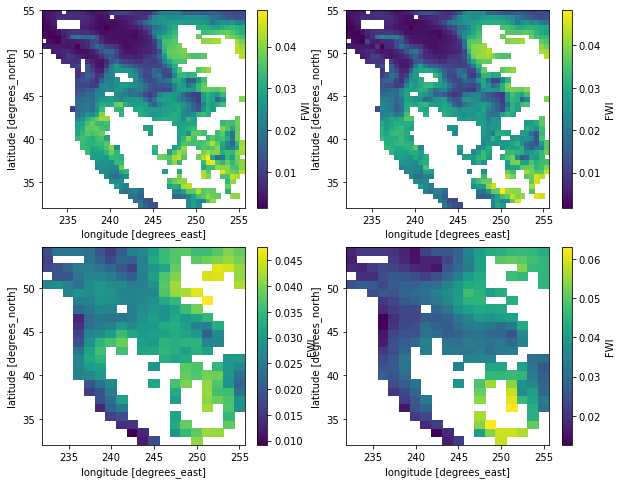

In [44]:
fig,axs = plt.subplots(2,2,figsize=(10,8))
axs = axs.flatten()

for i,da in enumerate([d4pdf_all_trend_ensSTD,d4pdf_nat_trend_ensSTD,cam5_all_trend_ensSTD,cam5_nat_trend_ensSTD]):
    
    da.plot(ax=axs[i])

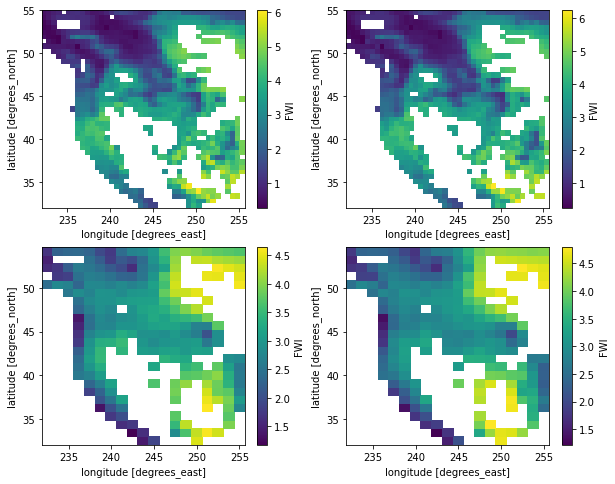

In [46]:
d4PDF_all_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/noise/absolute_noise/FWI_absolute_noise_HPB_ensMean.nc')
d4PDF_nat_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/noise/absolute_noise/FWI_absolute_noise_HPB_NAT_ensMean.nc')
cam5_all_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/noise/absolute_noise/FWI_absolute_noise_All_ensMean.nc')
cam5_nat_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/noise/absolute_noise/FWI_absolute_noise_Nat_ensMean.nc')

fig,axs = plt.subplots(2,2,figsize=(10,8))
axs = axs.flatten()

for i,da in enumerate([d4PDF_all_mean,d4PDF_nat_mean,cam5_all_mean,cam5_nat_mean]):
    
    da.mean('time').plot(ax=axs[i])

In [47]:
cam5_all_mean == cam5_nat_mean

<xarray.DataArray 'FWI' (time: 56, lev: 1, latitude: 24, longitude: 19)>
array([[[[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]],


       [[[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]],


       [[[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
...
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]],


       [[[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]],


       [[[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]]])
Coordinates:
  * time       (time) datetime64[ns] 1959-12-31 1960-12-31 ... 2014-12-31
  * longitude  (longitude) float32 232.5 233.8 235.0 236.2 ... 252.5 253.8 255.0
  * latitude   (latitude) float32 32.51 33.46 34.4 35.34 ... 52.3 53.25 54.19
Dimensions without coordinates: lev

In [14]:
def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)

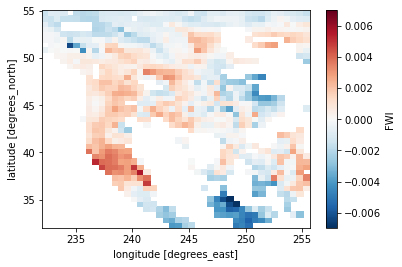

In [15]:
xr.apply_ufunc(get_linregress_slope, d4PDF_all_mean, input_core_dims=[["time"]], vectorize = True).plot()#ax=axs[i][j+2],vmin=-0.06,vmax=0.06,cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)


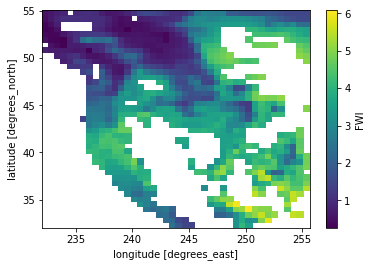

In [19]:
d4PDF_all_mean.mean('time').plot()

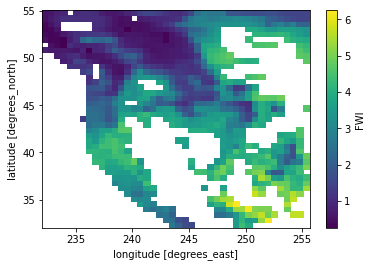

In [20]:
d4PDF_nat_mean.mean('time').plot()

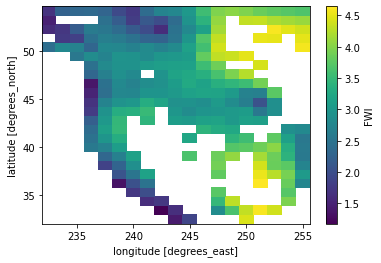

In [21]:
cam5_all_mean.mean('time').plot()

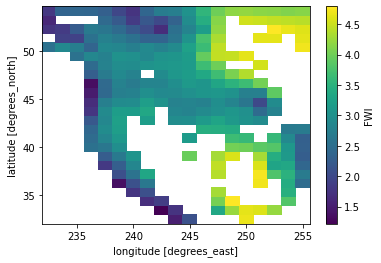

In [22]:
cam5_nat_mean.mean('time').plot()